Téléchargement du Dataset MovieLens

In [2]:
import torch
import pandas as pd
import numpy as np
import scipy.sparse as sp
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import zipfile

print("PyTorch   :", torch.__version__)
print("GPU dispo :", torch.cuda.is_available())
print("Nom GPU   :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Aucun")

# Téléchargement MovieLens
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
urllib.request.urlretrieve(url, "ml-latest-small.zip")
print("\nTéléchargement terminé ")

# Extraction
with zipfile.ZipFile("ml-latest-small.zip", "r") as z:
    z.extractall(".")
print("Extraction terminée ")

# Vérification
df = pd.read_csv("ml-latest-small/ratings.csv")
print("\nColonnes :", df.columns.tolist())
print("Nombre de lignes :", len(df))
print("\nAperçu :")
print(df.head())

PyTorch   : 2.11.0+cu128
GPU dispo : True
Nom GPU   : Tesla T4

Téléchargement terminé 
Extraction terminée 

Colonnes : ['userId', 'movieId', 'rating', 'timestamp']
Nombre de lignes : 100836

Aperçu :
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [3]:
# Exploration complète du dataset

print("=" * 50)
print("STRUCTURE DU DATASET")
print("=" * 50)

print(f"\nNombre de lignes     : {len(df)}")
print(f"Nombre d'utilisateurs: {df['userId'].nunique()}")
print(f"Nombre de films      : {df['movieId'].nunique()}")
print(f"Notes min / max      : {df['rating'].min()} / {df['rating'].max()}")
print(f"Note moyenne         : {df['rating'].mean():.2f}")

print("\n── Distribution des notes ──")
print(df['rating'].value_counts().sort_index())

print("\n── Exemple de données brutes ──")
print(df.head(10))

STRUCTURE DU DATASET

Nombre de lignes     : 100836
Nombre d'utilisateurs: 610
Nombre de films      : 9724
Notes min / max      : 0.5 / 5.0
Note moyenne         : 3.50

── Distribution des notes ──
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

── Exemple de données brutes ──
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
5       1       70     3.0  964982400
6       1      101     5.0  964980868
7       1      110     4.0  964982176
8       1      151     5.0  964984041
9       1      157     5.0  964984100


In [4]:
# Préparation des données

# ÉTAPE A : Binarisation
# On garde uniquement les notes >= 3.5 car on veut modéliser les films que l'utilisateur a aimé, pas toutes les interactions.
df_pos = df[df['rating'] >= 3.5][['userId', 'movieId']].copy()
print(f"Interactions positives : {len(df_pos)} (sur {len(df)} au total)")
print(f"Soit {len(df_pos)/len(df)*100:.1f}% des données conservées\n")

# ÉTAPE B : Réencodage des IDs
# Les userId vont de 1 à 610 mais avec des trous (ex: 1,2,3,5,6...)
# Les movieId vont de 1 à 193609 avec beaucoup de trous
# On les réencode en indices contigus : 0,1,2,3,4,... pour que le modèle utilise ces IDs comme indices dans une table d'embeddings.
df_pos['user_idx'] = pd.Categorical(df_pos['userId']).codes
df_pos['item_idx'] = pd.Categorical(df_pos['movieId']).codes

n_users = df_pos['user_idx'].nunique()
n_items = df_pos['item_idx'].nunique()

print(f"Nombre d'utilisateurs : {n_users}")
print(f"Nombre de films       : {n_items}")
print(f"\nExemple d'encodage :")
print(df_pos[['userId','user_idx','movieId','item_idx']].head(8))

# ÉTAPE C : Split train / test (80% / 20%)
# Pour chaque utilisateur, on prend 80% de ses films pour entraîner et 20% pour évaluer.
train_data, test_data = [], []

for uid, group in df_pos.groupby('user_idx'):
    items = group['item_idx'].tolist()

    # Si l'utilisateur a noté moins de 2 films, on met tout en train
    if len(items) < 2:
        train_data.extend([(uid, i) for i in items])
        continue

    # Sinon : 80% en train, 20% en test
    split = max(1, int(0.8 * len(items)))
    train_data.extend([(uid, i) for i in items[:split]])
    test_data.extend([(uid, i) for i in items[split:]])

train_df = pd.DataFrame(train_data, columns=['user_idx', 'item_idx'])
test_df  = pd.DataFrame(test_data,  columns=['user_idx', 'item_idx'])

print(f"\n── Split train / test ──")
print(f"Train : {len(train_df)} interactions")
print(f"Test  : {len(test_df)} interactions")
print(f"Ratio : {len(train_df)/(len(train_df)+len(test_df))*100:.1f}% / "
      f"{len(test_df)/(len(train_df)+len(test_df))*100:.1f}%")

Interactions positives : 61716 (sur 100836 au total)
Soit 61.2% des données conservées

Nombre d'utilisateurs : 609
Nombre de films       : 7363

Exemple d'encodage :
   userId  user_idx  movieId  item_idx
0       1         0        1         0
1       1         0        3         2
2       1         0        6         4
3       1         0       47        41
4       1         0       50        43
6       1         0      101        81
7       1         0      110        88
8       1         0      151       107

── Split train / test ──
Train : 49125 interactions
Test  : 12591 interactions
Ratio : 79.6% / 20.4%


In [5]:
# Construction du graphe biparti normalisé

import scipy.sparse as sp
import torch

def build_adj_matrix(train_df, n_users, n_items):
    """
    Construit la matrice d'adjacence normalisée du graphe biparti.

    Le graphe a (n_users + n_items) nœuds.
    Les n_users premiers nœuds = utilisateurs.
    Les n_items suivants       = films.

    La matrice ressemble à :
         users   items
    users [  0  |  R  ]
    items [ R^T |  0  ]

    où R[u,i] = 1 si l'utilisateur u a aimé le film i.
    """

    rows = train_df['user_idx'].values
    cols = train_df['item_idx'].values

    # ÉTAPE 1 : Matrice d'interaction R (users x items)
    # R[u, i] = 1 si l'utilisateur u a interagi avec le film i
    R = sp.csr_matrix(
        (np.ones(len(rows)), (rows, cols)),
        shape=(n_users, n_items)
    )
    print(f"Matrice R : {R.shape[0]} utilisateurs × {R.shape[1]} films")
    print(f"Densité   : {R.nnz / (R.shape[0]*R.shape[1]) * 100:.4f}%")

    # ÉTAPE 2 : Construction du graphe biparti symétrique
    # On assemble les 4 blocs :
    # [ 0   R  ]
    # [ R^T 0  ]
    zeros_uu = sp.csr_matrix((n_users, n_users))  # bloc vide users-users
    zeros_ii = sp.csr_matrix((n_items, n_items))  # bloc vide items-items

    A = sp.bmat([
        [zeros_uu, R      ],
        [R.T,      zeros_ii]
    ], format='csr')

    print(f"\nMatrice A (graphe complet) : {A.shape}")
    print(f"Nombre d'arêtes : {A.nnz // 2}")

    # ÉTAPE 3 : Normalisation D^{-1/2} A D^{-1/2}
    # Un utilisateur qui a noté 500 films a un degré très élevé.
    # Sans normalisation, ses voisins reçoivent trop d'information.
    # La normalisation équilibre la contribution de chaque nœud.
    #
    # D = matrice diagonale des degrés (nombre de connexions par nœud)
    # D^{-1/2}[i,i] = 1 / sqrt(degré du nœud i)
    deg = np.array(A.sum(axis=1)).flatten()      # degré de chaque nœud
    deg_inv_sqrt = np.where(deg > 0, 1.0 / np.sqrt(deg), 0.0)
    D = sp.diags(deg_inv_sqrt)                   # matrice diagonale

    A_norm = D @ A @ D   # normalisation symétrique

    # ÉTAPE 4 : Conversion en tenseur PyTorch sparse
    # PyTorch ne comprend pas les matrices SciPy.
    # On convertit au format COO (liste de coordonnées).
    A_coo = A_norm.tocoo()
    indices = torch.LongTensor(np.vstack([A_coo.row, A_coo.col]))
    values  = torch.FloatTensor(A_coo.data)
    size    = torch.Size(A_coo.shape)

    adj = torch.sparse_coo_tensor(indices, values, size)
    print(f"\nTenseur sparse PyTorch : {adj.shape}")
    print(" Graphe construit !")
    return adj

# Construction
adj = build_adj_matrix(train_df, n_users, n_items)

Matrice R : 609 utilisateurs × 7363 films
Densité   : 1.0955%

Matrice A (graphe complet) : (7972, 7972)
Nombre d'arêtes : 49125

Tenseur sparse PyTorch : torch.Size([7972, 7972])
 Graphe construit !


/tmp/ipykernel_2502/701898590.py:57: RuntimeWarning: divide by zero encountered in divide
  deg_inv_sqrt = np.where(deg > 0, 1.0 / np.sqrt(deg), 0.0)
/tmp/ipykernel_2502/701898590.py:70: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  adj = torch.sparse_coo_tensor(indices, values, size)


In [6]:
# Modèle LightGCN

import torch
import torch.nn as nn

class LightGCN(nn.Module):

    def __init__(self, n_users, n_items, emb_dim=64, n_layers=3):
        """
        n_users  : nombre d'utilisateurs (609)
        n_items  : nombre de films (7363)
        emb_dim  : dimension des embeddings (64 = vecteur de taille 64)
        n_layers : nombre de couches de propagation (3)
        """
        super().__init__()
        self.n_users  = n_users
        self.n_items  = n_items
        self.n_layers = n_layers

        # Embeddings initiaux (couche 0)
        # Chaque utilisateur et chaque film est représenté par un vecteur de dimension emb_dim.
        # Ce sont les SEULS paramètres appris par le modèle.
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)

        # Initialisation Xavier : meilleure convergence que les valeurs
        # aléatoires par défaut (évite les gradients trop grands/petits)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

        print(f"Modèle LightGCN créé :")
        print(f"  - {n_users} utilisateurs × {emb_dim} dims")
        print(f"  - {n_items} films × {emb_dim} dims")
        print(f"  - {n_layers} couches de propagation")
        total_params = n_users * emb_dim + n_items * emb_dim
        print(f"  - {total_params:,} paramètres au total")

    def forward(self, adj):
        """
        Propagation dans le graphe.
        adj : matrice d'adjacence normalisée (7972 × 7972)

        Retourne les embeddings finaux des users et des items.
        """

        # On concatène users et items en un seul vecteur
        # Taille : (n_users + n_items) × emb_dim = 7972 × 64
        emb_0 = torch.cat([self.user_emb.weight,
                            self.item_emb.weight], dim=0)

        # On stocke tous les embeddings couche par couche
        all_embs = [emb_0]

        emb = emb_0
        for layer in range(self.n_layers):
            # Propagation : chaque nœud agrège ses voisins
            emb = torch.sparse.mm(adj, emb)
            all_embs.append(emb)

        # Agrégation finale : moyenne de toutes les couches
        # Chaque couche capture une "portée" différente :
        # - couche 0 : embedding initial
        # - couche 1 : voisins directs (films notés / users ayant noté)
        # - couche 2 : voisins de voisins
        # - couche 3 : voisins de voisins de voisins
        final_emb = torch.stack(all_embs, dim=1).mean(dim=1)

        # On sépare à nouveau users et items
        u_emb = final_emb[:self.n_users]   # 609 × 64
        i_emb = final_emb[self.n_users:]   # 7363 × 64

        return u_emb, i_emb

    def bpr_loss(self, u_emb, i_emb, users, pos_items, neg_items):
        """
        Perte BPR (Bayesian Personalized Ranking).

        Idée : pour chaque utilisateur u, on veut que son score
        avec un film qu'il a aimé (pos) soit SUPÉRIEUR à son score
        avec un film aléatoire qu'il n'a pas vu (neg).

        score(u, i) = produit scalaire entre u_emb[u] et i_emb[i]

        Perte = -log(sigmoid(score_pos - score_neg))
        → minimisée quand score_pos >> score_neg
        """
        u  = u_emb[users]       # embeddings des utilisateurs du batch
        pi = i_emb[pos_items]   # embeddings des films positifs
        ni = i_emb[neg_items]   # embeddings des films négatifs

        # Score = produit scalaire (similarité entre user et film)
        pos_score = (u * pi).sum(dim=1)   # score utilisateur-film aimé
        neg_score = (u * ni).sum(dim=1)   # score utilisateur-film aléatoire

        # On veut maximiser (pos - neg), donc minimiser -log(sigmoid(...))
        loss = -torch.log(torch.sigmoid(pos_score - neg_score) + 1e-8).mean()

        # Régularisation L2 : évite que les embeddings deviennent trop grands
        reg = (u.norm(2).pow(2) +
               pi.norm(2).pow(2) +
               ni.norm(2).pow(2)) / len(users)

        return loss + 1e-4 * reg


# Instanciation du modèle
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {device}\n")

model = LightGCN(n_users, n_items, emb_dim=64, n_layers=3).to(device)
adj_gpu = adj.to(device)

Device utilisé : cuda

Modèle LightGCN créé :
  - 609 utilisateurs × 64 dims
  - 7363 films × 64 dims
  - 3 couches de propagation
  - 510,208 paramètres au total


Début de l'entraînement...
Époque |     Loss | Meilleur
--------------------------------
     1 |   0.6929 |   0.6929 ★
    10 |   0.6916 |   0.6916 ★
    20 |   0.6850 |   0.6850 ★
    30 |   0.6682 |   0.6682 ★
    40 |   0.6449 |   0.6449 ★
    50 |   0.6099 |   0.6099 ★
    60 |   0.5630 |   0.5630 ★
    70 |   0.5219 |   0.5175
    80 |   0.4687 |   0.4687 ★
    90 |   0.4318 |   0.4318 ★
   100 |   0.4043 |   0.3949

✅ Entraînement terminé !
Meilleure loss : 0.3949
Modèle sauvegardé dans best_model.pt


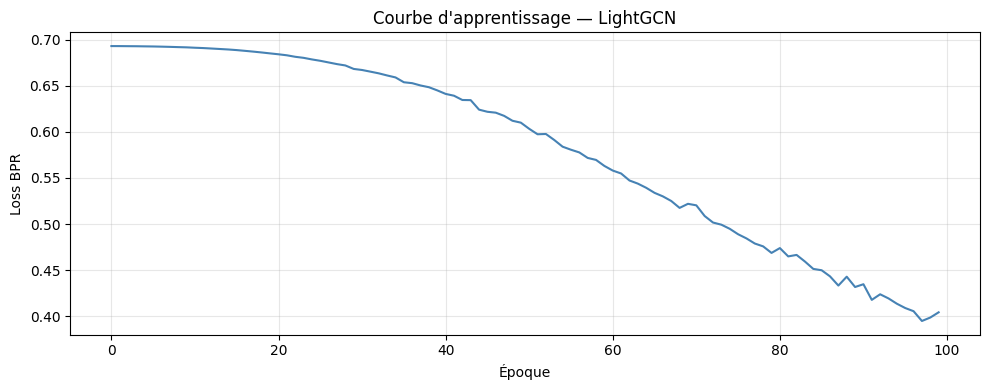

Courbe sauvegardée ✅


In [7]:
# ÉTAPE 4 — ENTRAÎNEMENT

import random

# Préparation : dictionnaire des films vus par chaque user
# On crée un dictionnaire { user_id : {set de films vus} }
# Indispensable pour l'échantillonnage négatif : quand on tire un film "négatif" au hasard, on vérifie qu'il
# n'a pas déjà été vu par l'utilisateur.
user_items_train = (train_df.groupby('user_idx')['item_idx']
                             .apply(set).to_dict())

def sample_batch(train_df, n_items, batch_size=2048):
    """
    Tire un batch de triplets (user, item_positif, item_negatif).

    - user et item_positif  : pris dans train_df (interactions réelles)
    - item_negatif          : tiré aléatoirement parmi les films
                              que l'utilisateur n'a PAS vus
    """
    sample = train_df.sample(batch_size)
    users, pos_items, neg_items = [], [], []

    for _, row in sample.iterrows():
        u = int(row['user_idx'])
        i = int(row['item_idx'])

        # Tirage négatif : on tire jusqu'à trouver un film non vu
        j = random.randint(0, n_items - 1)
        while j in user_items_train.get(u, set()):
            j = random.randint(0, n_items - 1)

        users.append(u)
        pos_items.append(i)
        neg_items.append(j)

    return (torch.LongTensor(users).to(device),
            torch.LongTensor(pos_items).to(device),
            torch.LongTensor(neg_items).to(device))

# Boucle d'entraînement
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs   = 100
batch_size = 2048
best_loss  = float('inf')
losses     = []   # pour tracer la courbe

print("Début de l'entraînement...")
print(f"{'Époque':>6} | {'Loss':>8} | {'Meilleur':>8}")
print("-" * 32)

for epoch in range(1, n_epochs + 1):

    model.train()   # mode entraînement (active les gradients)

    # 1. Propagation dans le graphe → embeddings
    u_emb, i_emb = model(adj_gpu)

    # 2. Tirage d'un batch de triplets
    users, pos_items, neg_items = sample_batch(train_df,
                                               n_items,
                                               batch_size)

    # 3. Calcul de la perte BPR
    loss = model.bpr_loss(u_emb, i_emb, users, pos_items, neg_items)

    # 4. Rétropropagation : calcul des gradients
    optimizer.zero_grad()   # remet les gradients à zéro
    loss.backward()         # calcule les gradients
    optimizer.step()        # met à jour les paramètres

    loss_val = loss.item()
    losses.append(loss_val)

    # 5. Sauvegarde du meilleur modèle
    if loss_val < best_loss:
        best_loss = loss_val
        torch.save(model.state_dict(), "best_model.pt")
        star = " ★"
    else:
        star = ""

    # Affichage toutes les 10 époques
    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6} | {loss_val:>8.4f} | {best_loss:>8.4f}{star}")

print("\n✅ Entraînement terminé !")
print(f"Meilleure loss : {best_loss:.4f}")
print("Modèle sauvegardé dans best_model.pt")

# Courbe de loss
plt.figure(figsize=(10, 4))
plt.plot(losses, color='steelblue', linewidth=1.5)
plt.xlabel("Époque")
plt.ylabel("Loss BPR")
plt.title("Courbe d'apprentissage — LightGCN")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150)
plt.show()
print("Courbe sauvegardée ✅")

In [8]:
# ÉVALUATION

def recall_ndcg_at_k(recs, ground_truth, k):
    """
    Calcule Recall@K et NDCG@K.

    recs         : dict { user_id : [liste de films recommandés] }
    ground_truth : dict { user_id : {set de films aimés dans le test} }
    k            : nombre de recommandations à considérer
    """
    recalls, ndcgs = [], []

    for uid, top_k in recs.items():
        gt = ground_truth.get(uid, set())
        if not gt:
            continue

        # Les K premières recommandations
        top_k_items = top_k[:k]

        # hits[i] = 1 si la recommandation i est dans les films aimés
        hits = [1 if item in gt else 0 for item in top_k_items]

        # Recall
        # Proportion des films aimés qu'on a retrouvés
        recall = sum(hits) / len(gt)
        recalls.append(recall)

        # NDCG
        # DCG : somme pondérée par la position (log2(rang+2))
        # Plus le bon film est haut dans la liste, plus le score est élevé
        dcg  = sum(h / np.log2(r + 2) for r, h in enumerate(hits))

        # IDCG : score parfait (tous les bons films en tête de liste)
        idcg = sum(1 / np.log2(r + 2) for r in range(min(len(gt), k)))

        ndcg = dcg / idcg if idcg > 0 else 0
        ndcgs.append(ndcg)

    return np.mean(recalls), np.mean(ndcgs)


# Génération des recommandations
model.eval()   # mode évaluation (désactive les gradients)

# Charger le meilleur modèle sauvegardé
model.load_state_dict(torch.load("best_model.pt"))
print("Meilleur modèle chargé ")

with torch.no_grad():   # pas de calcul de gradients → plus rapide
    u_emb, i_emb = model(adj_gpu)

    # Score de chaque utilisateur pour chaque film
    # scores[u, i] = u_emb[u] · i_emb[i] (produit scalaire)
    # Plus le score est élevé, plus le film est recommandé
    scores = torch.mm(u_emb, i_emb.T)   # (609 × 7363)
    print(f"Matrice de scores : {scores.shape}")

    # Masquer les films déjà vus dans le train
    # On met leur score à -∞ pour qu'ils ne soient jamais recommandés
    # (on ne veut pas recommander un film que l'utilisateur a déjà vu)
    for uid, seen_items in user_items_train.items():
        scores[uid, list(seen_items)] = -float('inf')

    # Top-20 recommandations pour chaque utilisateur
    top20 = scores.topk(20, dim=1).indices.cpu().numpy()

print("Recommandations générées ")

# Calcul des métriques
# Ground truth : films aimés dans le test (inconnus pendant l'entraînement)
ground_truth = (test_df.groupby('user_idx')['item_idx']
                        .apply(set).to_dict())

recs = {uid: list(top20[uid]) for uid in range(n_users)}

print("\n" + "=" * 40)
print("RÉSULTATS — LightGCN")
print("=" * 40)

for k in [10, 20]:
    r, n = recall_ndcg_at_k(recs, ground_truth, k)
    print(f"Recall@{k:<2} : {r:.4f}   NDCG@{k:<2} : {n:.4f}")

# Baseline : popularité
# Comparaison avec une méthode simple : recommander les films
# les plus populaires (les plus notés dans le train).
# Si LightGCN ne bat pas cette baseline, c'est un problème.
print("\n" + "=" * 40)
print("BASELINE — Popularité")
print("=" * 40)

item_popularity = train_df['item_idx'].value_counts()
popular_items   = item_popularity.index.tolist()[:20]
recs_pop = {uid: popular_items for uid in range(n_users)}

for k in [10, 20]:
    r, n = recall_ndcg_at_k(recs_pop, ground_truth, k)
    print(f"Recall@{k:<2} : {r:.4f}   NDCG@{k:<2} : {n:.4f}")

print("\n" + "=" * 40)
print("COMPARAISON")
print("=" * 40)
r_lgcn, n_lgcn = recall_ndcg_at_k(recs, ground_truth, 10)
r_pop,  n_pop  = recall_ndcg_at_k(recs_pop, ground_truth, 10)
print(f"LightGCN améliore la baseline de :")
print(f"  Recall@10 : +{(r_lgcn - r_pop)*100:.1f}%")
print(f"  NDCG@10   : +{(n_lgcn - n_pop)*100:.1f}%")

Meilleur modèle chargé 
Matrice de scores : torch.Size([609, 7363])
Recommandations générées 

RÉSULTATS — LightGCN
Recall@10 : 0.0266   NDCG@10 : 0.0220
Recall@20 : 0.0530   NDCG@20 : 0.0342

BASELINE — Popularité
Recall@10 : 0.0189   NDCG@10 : 0.0126
Recall@20 : 0.0427   NDCG@20 : 0.0221

COMPARAISON
LightGCN améliore la baseline de :
  Recall@10 : +0.8%
  NDCG@10   : +0.9%


Modèle LightGCN créé :
  - 609 utilisateurs × 64 dims
  - 7363 films × 64 dims
  - 3 couches de propagation
  - 510,208 paramètres au total
Réentraînement avec 300 époques...
Époque |     Loss | Meilleur
--------------------------------
     1 |   0.6929 |   0.6929 ★
    50 |   0.5944 |   0.5944 ★
   100 |   0.3830 |   0.3830 ★
   150 |   0.3073 |   0.2962
   200 |   0.2941 |   0.2767
   250 |   0.2715 |   0.2603
   300 |   0.2659 |   0.2563

✅ Terminé ! Meilleure loss : 0.2563


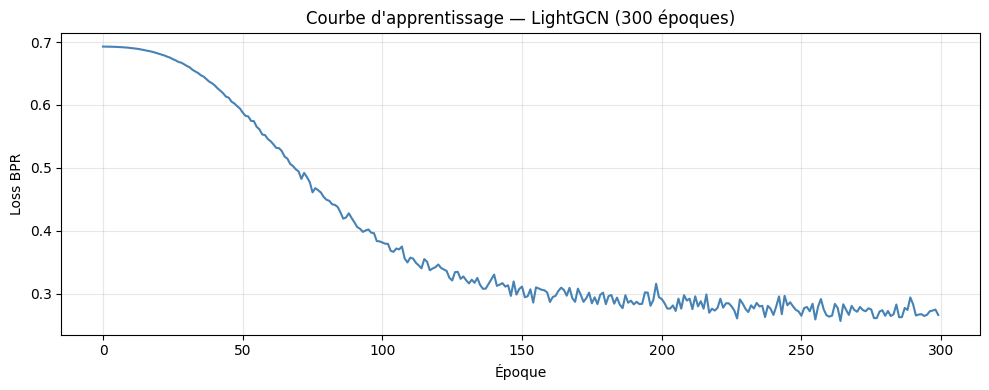

In [9]:
# RÉENTRAÎNEMENT AMÉLIORÉ

# On recrée le modèle proprement
model = LightGCN(n_users, n_items, emb_dim=64, n_layers=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs   = 300
batch_size = 4096   # batch plus grand = gradients plus stables
best_loss  = float('inf')
losses     = []

print("Réentraînement avec 300 époques...")
print(f"{'Époque':>6} | {'Loss':>8} | {'Meilleur':>8}")
print("-" * 32)

for epoch in range(1, n_epochs + 1):
    model.train()
    u_emb, i_emb = model(adj_gpu)
    users, pos_items, neg_items = sample_batch(train_df, n_items, batch_size)
    loss = model.bpr_loss(u_emb, i_emb, users, pos_items, neg_items)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_val = loss.item()
    losses.append(loss_val)

    if loss_val < best_loss:
        best_loss = loss_val
        torch.save(model.state_dict(), "best_model.pt")
        star = " ★"
    else:
        star = ""

    if epoch % 50 == 0 or epoch == 1:
        print(f"{epoch:>6} | {loss_val:>8.4f} | {best_loss:>8.4f}{star}")

print(f"\n✅ Terminé ! Meilleure loss : {best_loss:.4f}")

# Courbe
plt.figure(figsize=(10, 4))
plt.plot(losses, color='steelblue', linewidth=1.5)
plt.xlabel("Époque")
plt.ylabel("Loss BPR")
plt.title("Courbe d'apprentissage — LightGCN (300 époques)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150)
plt.show()

In [10]:
# ÉVALUATION APRÈS 300 ÉPOQUES

model.eval()
model.load_state_dict(torch.load("best_model.pt"))

with torch.no_grad():
    u_emb, i_emb = model(adj_gpu)
    scores = torch.mm(u_emb, i_emb.T)

    # Masquer les films déjà vus
    for uid, seen_items in user_items_train.items():
        scores[uid, list(seen_items)] = -float('inf')

    top20 = scores.topk(20, dim=1).indices.cpu().numpy()

recs = {uid: list(top20[uid]) for uid in range(n_users)}

print("=" * 40)
print("RÉSULTATS — LightGCN (300 époques)")
print("=" * 40)
for k in [10, 20]:
    r, n = recall_ndcg_at_k(recs, ground_truth, k)
    print(f"Recall@{k:<2} : {r:.4f}   NDCG@{k:<2} : {n:.4f}")

print("\n" + "=" * 40)
print("BASELINE — Popularité")
print("=" * 40)
for k in [10, 20]:
    r, n = recall_ndcg_at_k(recs_pop, ground_truth, k)
    print(f"Recall@{k:<2} : {r:.4f}   NDCG@{k:<2} : {n:.4f}")

print("\n" + "=" * 40)
print("COMPARAISON")
print("=" * 40)
r_lgcn, n_lgcn = recall_ndcg_at_k(recs, ground_truth, 10)
r_pop,  n_pop  = recall_ndcg_at_k(recs_pop, ground_truth, 10)
print(f"  Recall@10 : LightGCN {r_lgcn:.4f} vs Baseline {r_pop:.4f} "
      f"(+{(r_lgcn-r_pop)*100:.1f}%)")
print(f"  NDCG@10   : LightGCN {n_lgcn:.4f} vs Baseline {n_pop:.4f} "
      f"(+{(n_lgcn-n_pop)*100:.1f}%)")

RÉSULTATS — LightGCN (300 époques)
Recall@10 : 0.0268   NDCG@10 : 0.0229
Recall@20 : 0.0538   NDCG@20 : 0.0349

BASELINE — Popularité
Recall@10 : 0.0189   NDCG@10 : 0.0126
Recall@20 : 0.0427   NDCG@20 : 0.0221

COMPARAISON
  Recall@10 : LightGCN 0.0268 vs Baseline 0.0189 (+0.8%)
  NDCG@10   : LightGCN 0.0229 vs Baseline 0.0126 (+1.0%)


Embeddings users : (609, 64)
Embeddings items : (7363, 64)

Calcul t-SNE en cours (peut prendre 1-2 minutes)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE terminé 


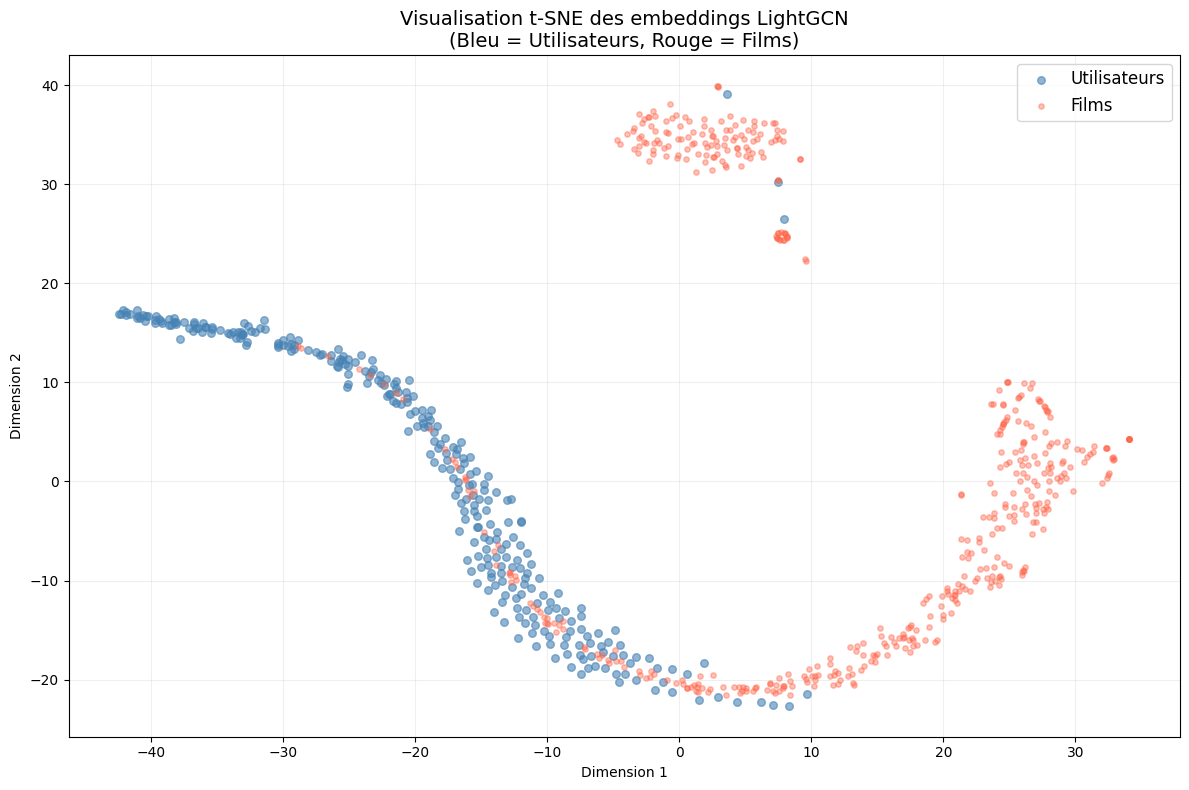

Figure sauvegardée : tsne_embeddings.png 


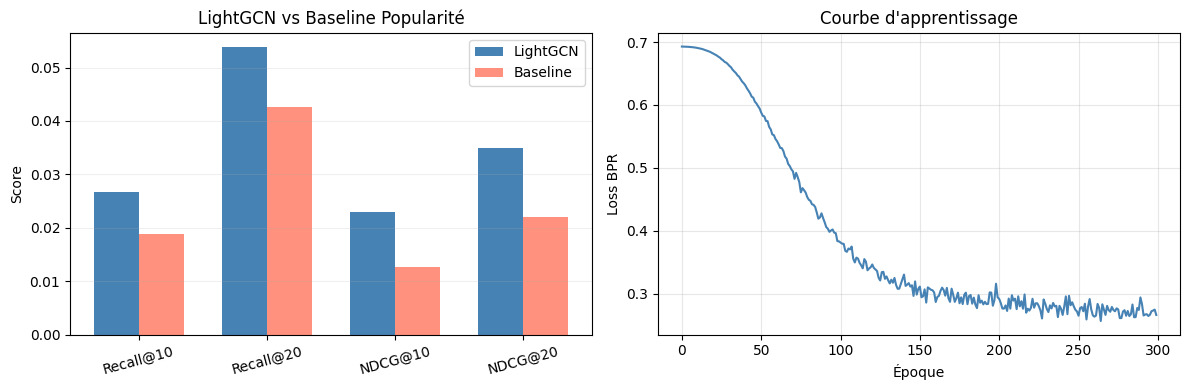

Figure sauvegardée : resultats_complets.png 


In [11]:
# ÉTAPE 6 — VISUALISATION DES EMBEDDINGS (t-SNE)

from sklearn.manifold import TSNE

# ── Récupération des embeddings finaux ──────────────────────────
model.eval()
with torch.no_grad():
    u_emb_np = u_emb.cpu().numpy()   # (609, 64)
    i_emb_np = i_emb.cpu().numpy()   # (7363, 64)

print(f"Embeddings users : {u_emb_np.shape}")
print(f"Embeddings items : {i_emb_np.shape}")

# ── t-SNE sur un échantillon ─────────────────────────────────────
# t-SNE réduit les vecteurs de 64 dimensions → 2 dimensions
# pour pouvoir les visualiser sur un plan.
# On prend 300 users et 500 items pour ne pas surcharger le graphe.

np.random.seed(42)
user_sample = np.random.choice(n_users, 300, replace=False)
item_sample = np.random.choice(n_items, 500, replace=False)

# On concatène users + items pour faire un seul t-SNE
combined = np.vstack([
    u_emb_np[user_sample],   # 300 users
    i_emb_np[item_sample]    # 500 items
])
labels = ['User'] * 300 + ['Film'] * 500

print("\nCalcul t-SNE en cours (peut prendre 1-2 minutes)...")
tsne = TSNE(n_components=2, random_state=42,
            perplexity=30, n_iter=1000)
coords = tsne.fit_transform(combined)
print("t-SNE terminé ")

# ── Visualisation ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

# Points utilisateurs
mask_u = np.array(labels) == 'User'
ax.scatter(coords[mask_u, 0], coords[mask_u, 1],
           c='steelblue', alpha=0.6, s=30, label='Utilisateurs')

# Points films
mask_i = np.array(labels) == 'Film'
ax.scatter(coords[mask_i, 0], coords[mask_i, 1],
           c='tomato', alpha=0.4, s=15, label='Films')

ax.set_title("Visualisation t-SNE des embeddings LightGCN\n"
             "(Bleu = Utilisateurs, Rouge = Films)", fontsize=14)
ax.legend(fontsize=12)
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("tsne_embeddings.png", dpi=150)
plt.show()
print("Figure sauvegardée : tsne_embeddings.png ")

# ── Courbe récapitulative des métriques ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

categories = ['Recall@10', 'Recall@20', 'NDCG@10', 'NDCG@20']
lgcn_scores = [0.0268, 0.0538, 0.0229, 0.0349]
base_scores = [0.0189, 0.0427, 0.0126, 0.0221]

# Remplace les valeurs ci-dessus par tes résultats exacts si différents

x = np.arange(len(categories))
width = 0.35

axes[0].bar(x - width/2, lgcn_scores, width,
            label='LightGCN', color='steelblue')
axes[0].bar(x + width/2, base_scores, width,
            label='Baseline', color='tomato', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=15)
axes[0].set_title("LightGCN vs Baseline Popularité")
axes[0].legend()
axes[0].set_ylabel("Score")
axes[0].grid(True, alpha=0.2, axis='y')

# Courbe de loss
axes[1].plot(losses, color='steelblue', linewidth=1.5)
axes[1].set_title("Courbe d'apprentissage")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Loss BPR")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("resultats_complets.png", dpi=150)
plt.show()
print("Figure sauvegardée : resultats_complets.png ")